# 1. Business Understanding

Financial institutions face significant challenges due to customer loan defaults, which impact
profitability and risk exposure. Predicting whether a borrower is likely to default on a loan is
essential for risk management, credit scoring, and decision-making.


This project focuses on building an automated loan default prediction system using machine
learning techniques to assess the probability

# 2. Importing Libraries

In [174]:
!pip install --upgrade pip
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [175]:
# pandas (pd) provides DataFrame data structures and data manipulation utilities.
import pandas as pd  # pd.DataFrame, pd.read_csv, pd.to_datetime, etc.

# numpy (np) provides numerical operations, random number generation, and arrays.
import numpy as np  # np.array, np.random, arithmetic operations

# matplotlib.pyplot for plotting (low-level plotting API). We use it for fine control.
import matplotlib.pyplot as plt  # plt.figure, plt.plot, plt.show

# seaborn is a statistical plotting library built on matplotlib; it provides high-level plot functions.
import seaborn as sns  # sns.histplot, sns.boxplot, sns.heatmap, sns.scatterplot

%matplotlib inline
sns.set(font_scale=1)
pd.set_option ('display.max_columns', None)
pd.set_option ('display.max_rows', None)

#import warnings to surpress warnings

import warnings
warnings.filterwarnings("ignore")

In [221]:
# joblib to save/load trained models efficiently.
import joblib  # joblib.dump, joblib.load

# pathlib.Path for file path manipulations in an OS-independent way.
from pathlib import Path  # Path('folder') to manage filesystem paths


# Define data and output directories using Path for convenience and portability.
BASE_DIR = Path('')  # current working directory
DATA_PATH = Path('loan_default_sample.csv')  # the CSV we saved earlier
OUTPUT_DIR = Path('output')  # folder to write cleaned data and models
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create output folder if it doesn't exist

# 3. EDA

## 3.1 Data Understanding

In [222]:
# Load dataset from CSV into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

# Show the number of rows and columns (shape): (rows, columns)
print('Shape:', df.shape)
print(f'row : {df.shape[0]}')
print(f'column : {df.shape[1]}')


# Display the first few rows for a quick sanity check. display() is Jupyter-friendly.
display(df.head(5))


Shape: (500, 14)
row : 500
column : 14


,loan_id,age,annual_income,employment_length,home_ownership,purpose,loan_amount,term_months,interest_rate,dti,credit_score,delinquency_2yrs,num_open_acc,target_default
0,L100000,24,48586.06,2,MORTGAGE,other,18943.19,60,13.31,17.75,746.0,3,7,0
1,L100001,55,23634.07,17,MORTGAGE,debt_consolidation,15802.09,36,14.34,13.33,713.0,1,14,0
2,L100002,49,27994.32,6,OWN,other,17309.60,36,8.37,18.95,601.0,3,12,1
3,L100003,40,81938.71,17,MORTGAGE,debt_consolidation,20443.27,36,12.15,20.54,717.0,3,12,0
4,L100004,40,30688.66,20,RENT,other,9333.60,36,5.00,11.73,552.0,4,1,1


In [177]:
# Checking the data types and unique values

summary = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique()
})
summary

,dtype,unique_values
loan_id,object,500
age,int64,44
annual_income,float64,494
employment_length,int64,30
home_ownership,object,3
purpose,object,4
loan_amount,float64,484
term_months,int64,2
interest_rate,float64,406
dti,float64,457


## 3.2 Numerical & Categorical Features

In [178]:
#Separate numerical & categorical features

num = df.select_dtypes(include=['int64','float64'])
cat = df.select_dtypes (include = ['object'])

# Convert columns to lists

num_col = num.columns.to_list()
cat_col = cat.columns.to_list()

### 3.2.1 Numerical Features

In [179]:
# Explore Numerical Features
print (f'rows: {num.shape[0]}')
print (f'columns: {num.shape[1]}')

#descriptive statistics of numerical features
num.describe().T

rows: 500
columns: 11


,count,mean,std,min,25%,50%,75%,max
age,500.0,42.45600,12.583670,21.0,32.0000,42.000,53.2500,64.00
annual_income,500.0,49372.77744,15221.358836,15000.0,38808.9075,49765.930,59155.7775,93576.01
employment_length,500.0,14.29000,8.727786,0.0,7.0000,14.000,22.0000,29.00
loan_amount,500.0,13913.15824,6834.649042,1000.0,9278.4075,14000.120,18607.7825,35399.71
term_months,500.0,43.00800,10.923304,36.0,36.0000,36.000,60.0000,60.00
interest_rate,500.0,12.28892,3.917982,5.0,9.4100,12.155,15.1425,24.24
dti,500.0,18.19742,7.774030,0.0,12.8125,18.130,23.5025,42.71
credit_score,500.0,679.89400,59.541255,522.0,636.0000,677.500,719.0000,850.00
delinquency_2yrs,500.0,2.00000,1.401402,0.0,1.0000,2.000,3.0000,4.00
num_open_acc,500.0,7.61200,4.055904,1.0,4.0000,8.000,11.0000,14.00


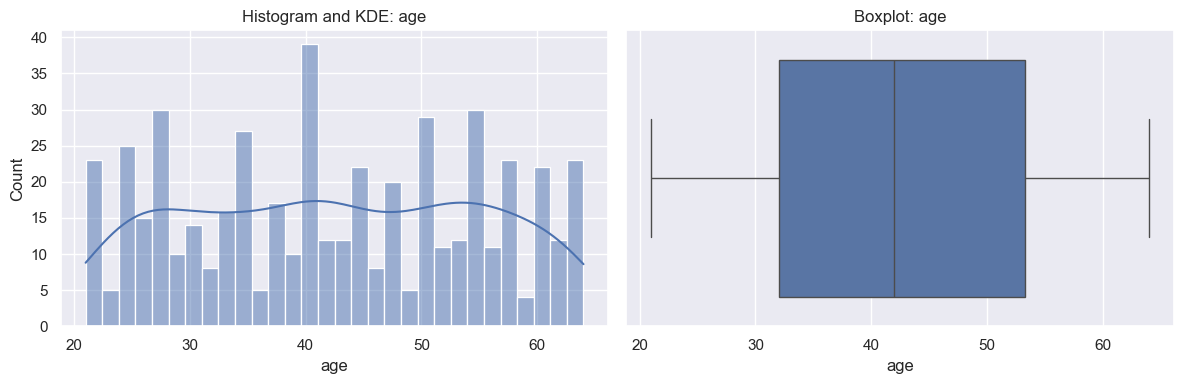

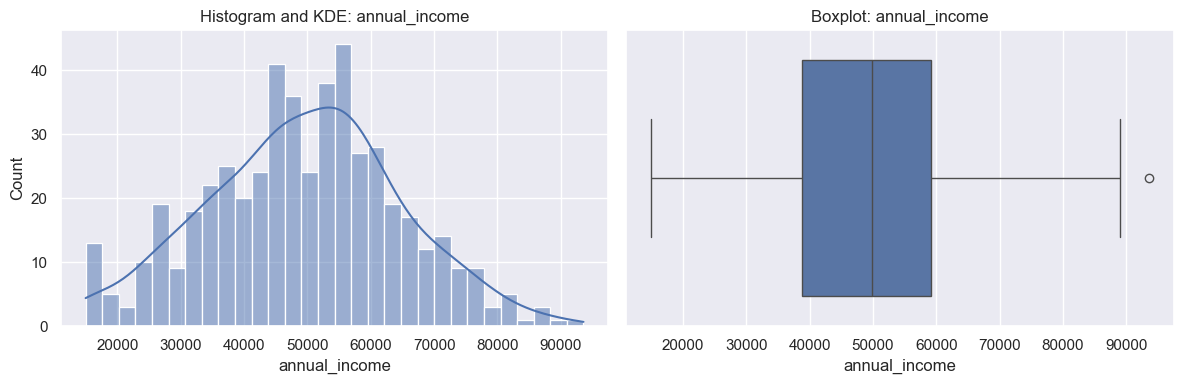

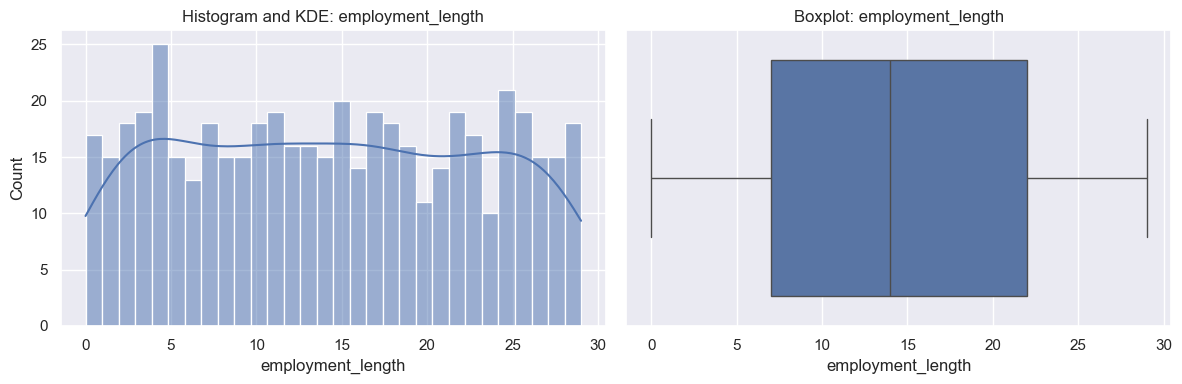

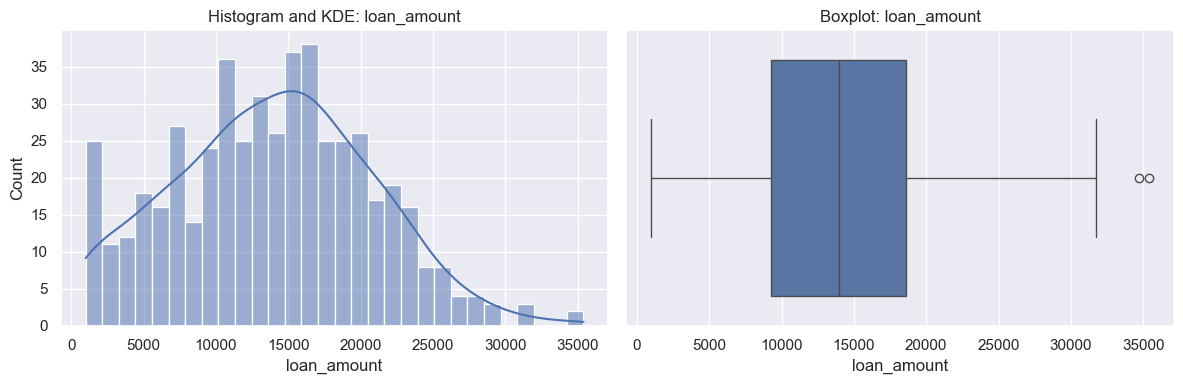

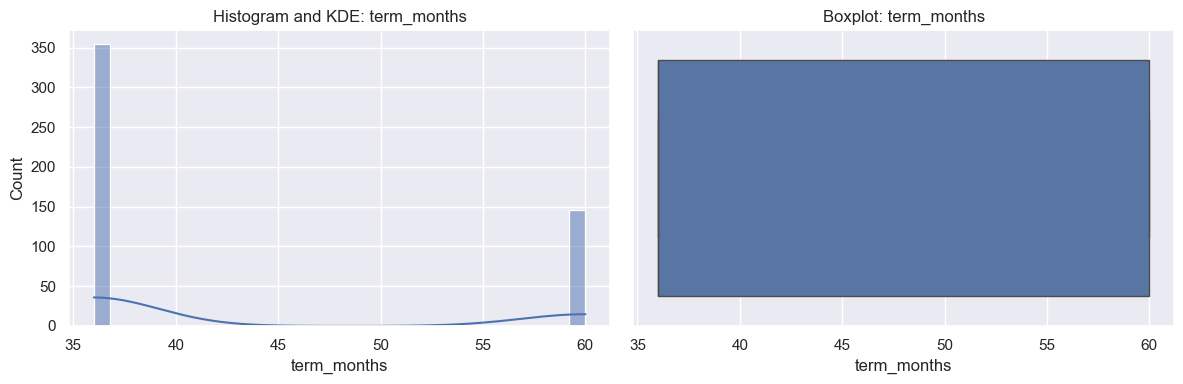

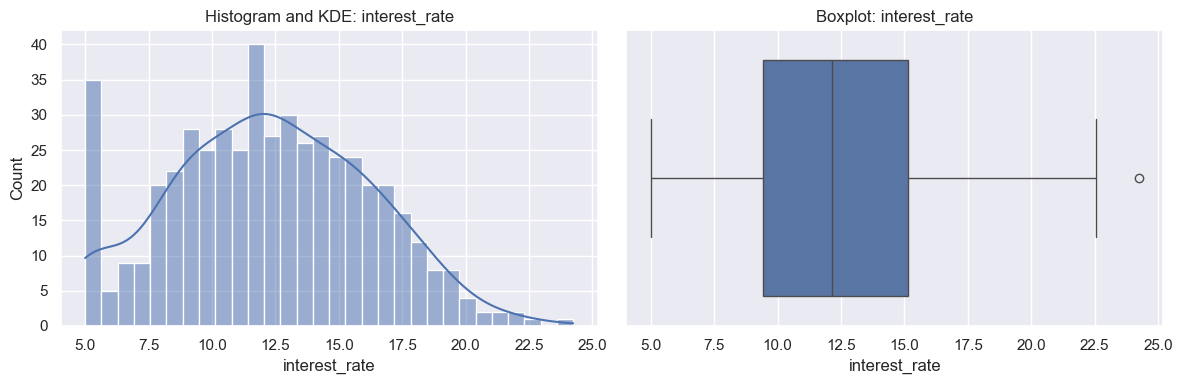

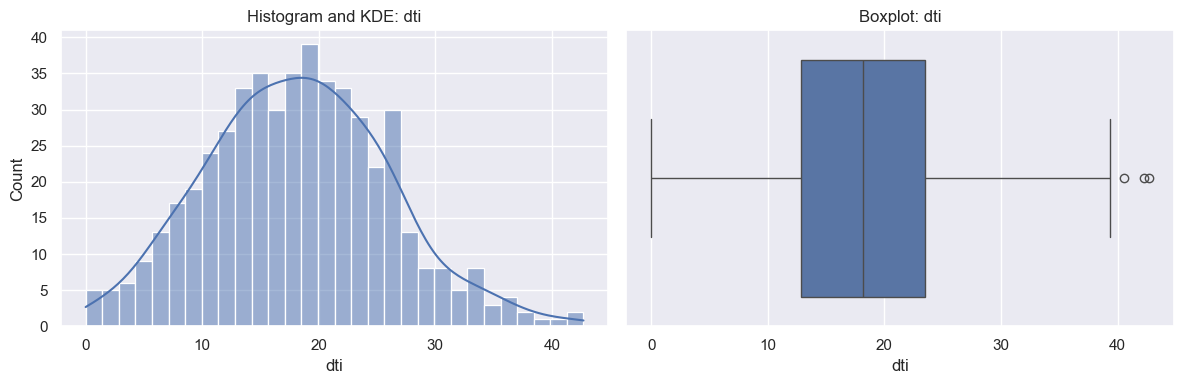

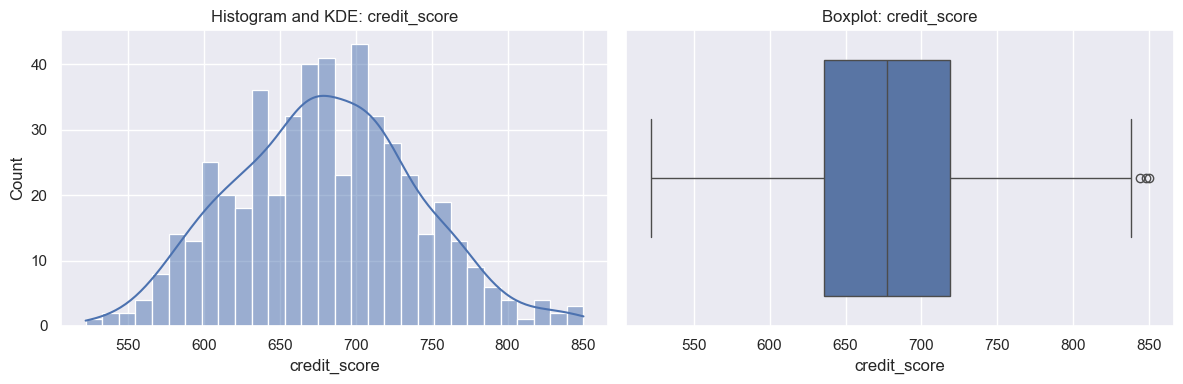

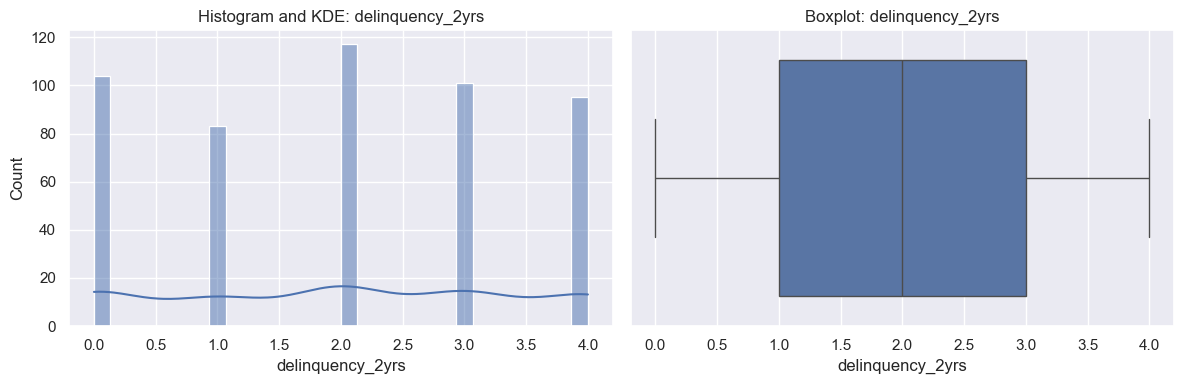

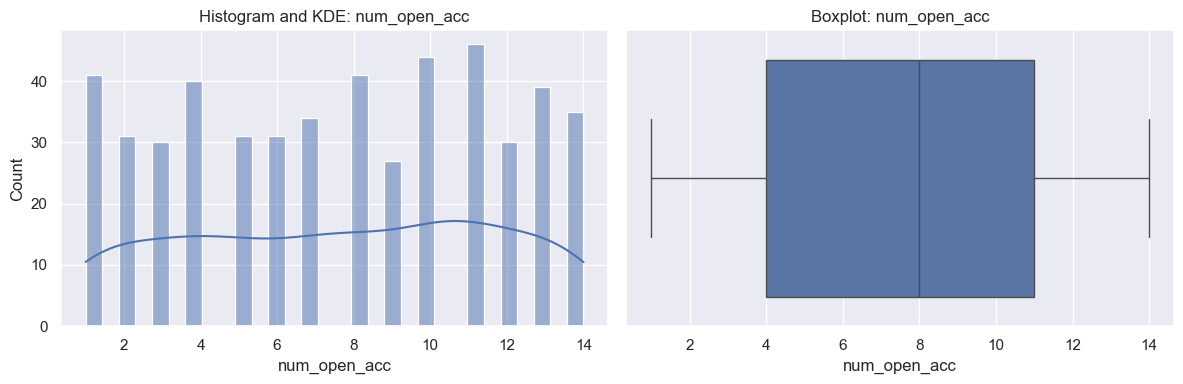

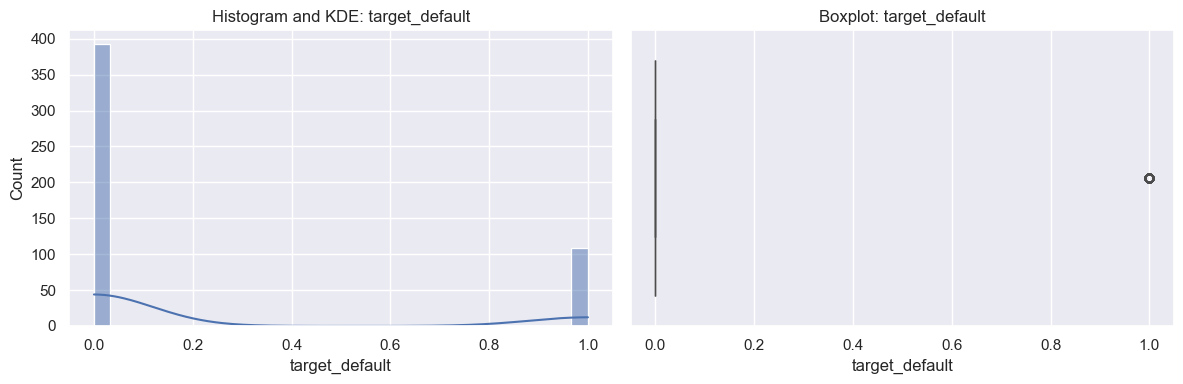

In [180]:
# Explanation: Univariate plots show the distribution of a single variable.
# Histograms reveal the distribution (counts) and kernel density estimate (KDE) shows smoothed density.
# Boxplots highlight median, quartiles, and potential outliers (whiskers).

#numeric_cols = ['age','years_experience','bonus','salary','performance_score','certifications']
num_col = [c for c in num_col if c in df.columns]  # ensure columns exist

for col in num_col:
    # Create a figure with two subplots side-by-side: histogram (left) and boxplot (right)
    plt.figure(figsize=(12,4))  # set the size of the figure (width, height in inches)
    
    # Histogram with seaborn: histplot uses matplotlib under the hood
    plt.subplot(1,2,1)  # left subplot
    sns.histplot(df[col].dropna(), kde=True, bins=30)  # dropna to avoid plotting NaNs
    plt.title(f'Histogram and KDE: {col}')
    plt.xlabel(col)
    
    # Boxplot: shows median and IQR and potential outliers
    plt.subplot(1,2,2)  # right subplot
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot: {col}')
    
    plt.tight_layout()  # adjust subplot params to fit in figure area
    plt.show()  # render the figure

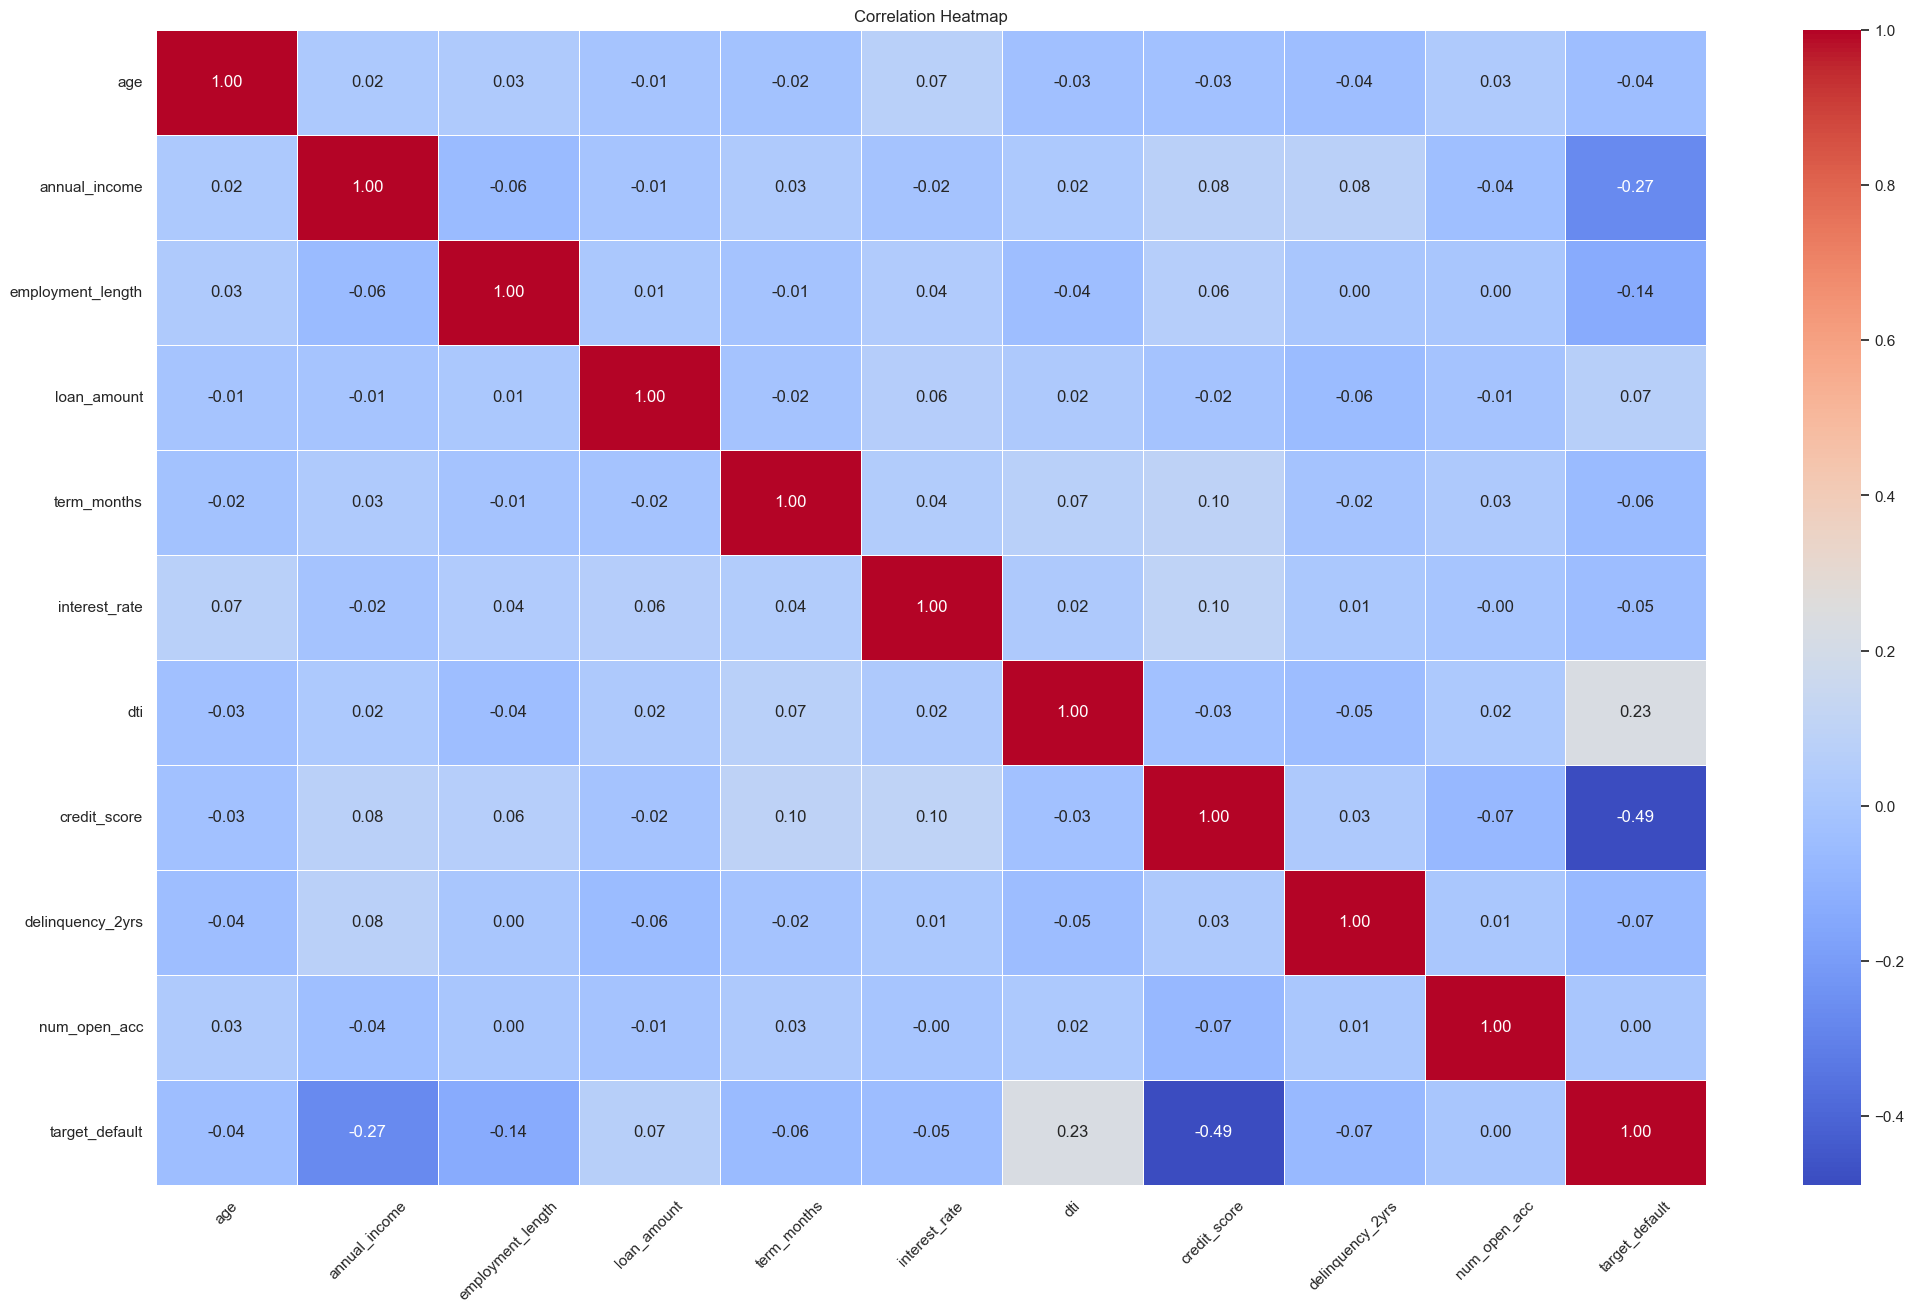

In [181]:
correlation = num.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [182]:
# Checking some columns further

#term_months
unique_term = df['term_months'].nunique()
print (f'number of unique in term_month feature: {unique_term}') 

#target_default

unique_target = df['target_default'].nunique()
print (f'number of unique values in target_default feature: {unique_target}')


number of unique in term_month feature: 2
number of unique values in target_default feature: 2


- Upon investigating further, the feature term_months only have 2 values, either 36 or 60 months. Even though in the data type is interger, but 36 or 60 should not be considered as numerical because it's a choice, either 36 or 60 months installment period. Thus, it will be considered as a categorical feature and will be transformed later in feature engineering step.

- For the feature target_default, it's binary as the target feature with 0 is for non-default and 1 is default. 

### 3.2.2 Categorical Features

In [183]:
# Explore categorical features
print (f'rows: {cat.shape[0]}')
print (f'columns:{cat.shape[1]}')

cat.describe().T


rows: 500
columns:3


,count,unique,top,freq
loan_id,500,500,L100499,1
home_ownership,500,3,OWN,179
purpose,500,4,other,135


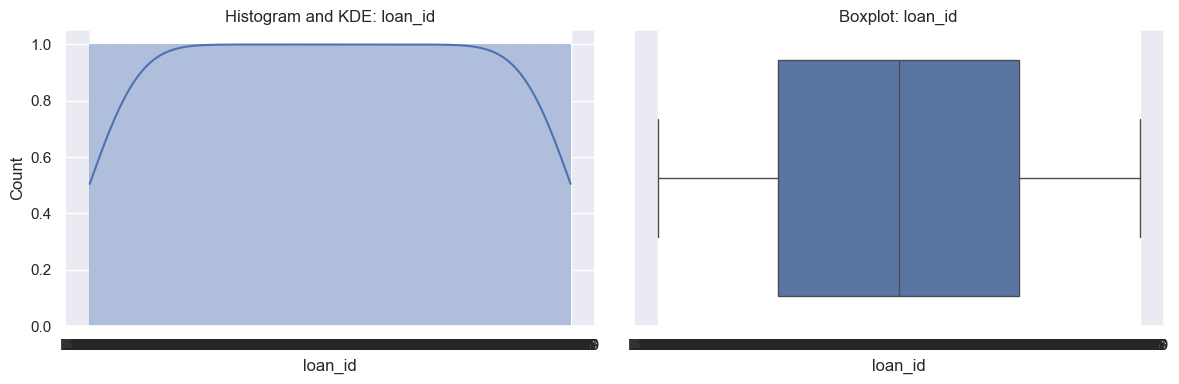

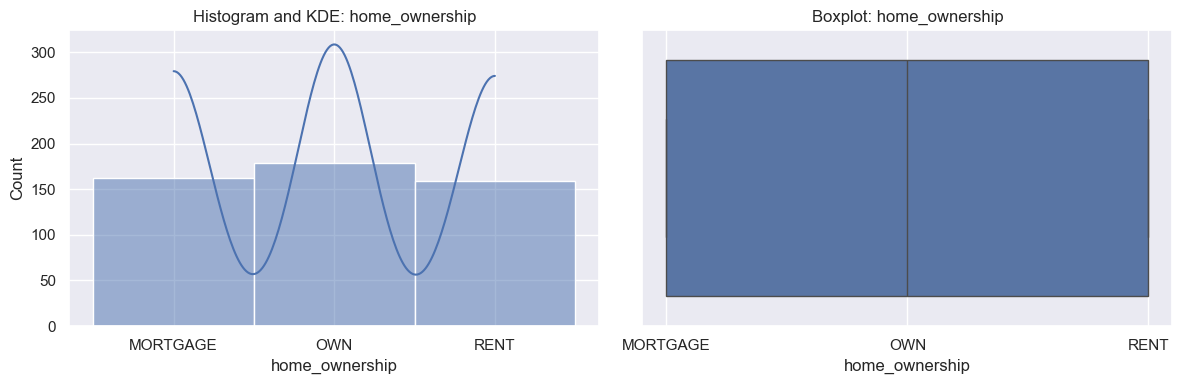

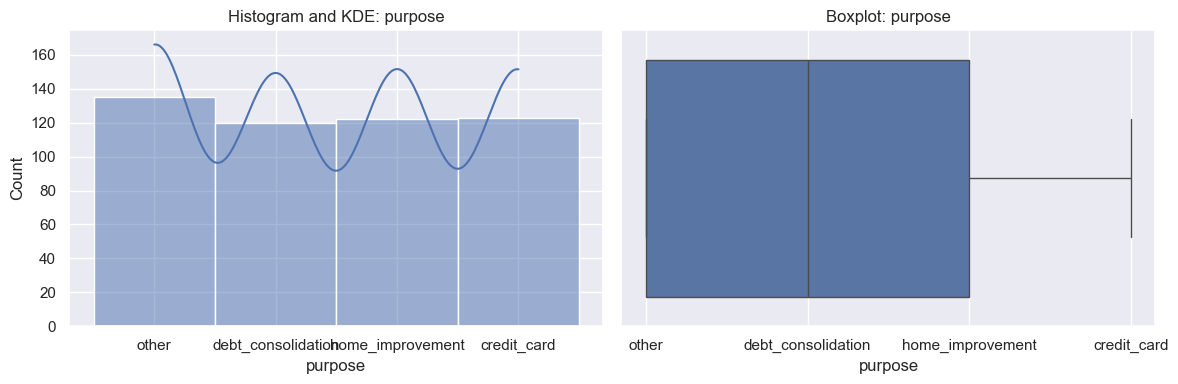

In [184]:
#numeric_cols = ['age','years_experience','bonus','salary','performance_score','certifications']
cat_col = [c for c in cat_col if c in df.columns]  # ensure columns exist

for col in cat_col:
    # Create a figure with two subplots side-by-side: histogram (left) and boxplot (right)
    plt.figure(figsize=(12,4))  # set the size of the figure (width, height in inches)
    
    # Histogram with seaborn: histplot uses matplotlib under the hood
    plt.subplot(1,2,1)  # left subplot
    sns.histplot(df[col].dropna(), kde=True, bins=30)  # dropna to avoid plotting NaNs
    plt.title(f'Histogram and KDE: {col}')
    plt.xlabel(col)
    
    # Boxplot: shows median and IQR and potential outliers
    plt.subplot(1,2,2)  # right subplot
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot: {col}')
    
    plt.tight_layout()  # adjust subplot params to fit in figure area
    plt.show()  # render the figure

From the information above, it shows that loan_id is too unique (identifier) for every row (loan), thus it will be dropped later on.

## 3.3 Data Cleaning

### 3.3.1 Duplicated Values

In [185]:
# Checking and removing duplicates in the dataset
df.duplicated().sum()


np.int64(0)

No duplicated value is found

### 3.3.2 Missing Values

In [186]:
#checking the total missing values in each feature
df.isnull().sum()

loan_id              0
age                  0
annual_income        0
employment_length    0
home_ownership       0
purpose              0
loan_amount          0
term_months          0
interest_rate        0
dti                  0
credit_score         0
delinquency_2yrs     0
num_open_acc         0
target_default       0
dtype: int64

No missing value is found

### 3.3.3 Irrelevant Features

Dropping Loan ID since it is all unique value and the ID of a loan is irrelevant in making the prediction

In [187]:
# drop loan_id feature

df = df.drop(columns=['loan_id'], axis=1)

# 4. Feature Engineering

Derived features include: 
- income_to_loan_ratio = annual_income / loan_amount 
- employment_risk = 1 if employment_length < 2 years else 0 
- credit_score_binned = categorical bands based on credit_score 

Features are standardized using StandardScaler and categorical variables encoded using 
OneHotEncoder. 

## 4.1 Feature: income_to_loan_ratio

In [188]:
#create a new feature income_to_loan_ratio = annual_income/ loan_amount

df['income_to_loan_ratio'] = df['annual_income']/df['loan_amount']

## 4.2 Feature: employment_risk 

In [189]:
# create a new feature employment_risk
# 1 if employment_length < 2 years else 0 
df['employment_risk'] = df['employment_length'].apply(
    lambda x: 1 if x < 2 else 0
)

## 4.3 Feature: credit_score_binned

The credit scores are grouped based on Five Levels of Personal Credit Score from this website: https://inszoneinsurance.com/blog/understanding-credit-scores

In [190]:
# create a new feature credit_score_binned = categorical bands based on credit_score

bins = [300, 580, 670, 740, 800,850]
labels = ['poor', 'fair', 'good', 'very good', 'excellent']


df['credit_score_binned'] = pd.cut(df['credit_score'], bins = bins, labels=labels)

In [191]:
df.head()

,age,annual_income,employment_length,home_ownership,purpose,loan_amount,term_months,interest_rate,dti,credit_score,delinquency_2yrs,num_open_acc,target_default,income_to_loan_ratio,employment_risk,credit_score_binned
0,24,48586.06,2,MORTGAGE,other,18943.19,60,13.31,17.75,746.0,3,7,0,2.564830,0,very good
1,55,23634.07,17,MORTGAGE,debt_consolidation,15802.09,36,14.34,13.33,713.0,1,14,0,1.495629,0,good
2,49,27994.32,6,OWN,other,17309.60,36,8.37,18.95,601.0,3,12,1,1.617271,0,fair
3,40,81938.71,17,MORTGAGE,debt_consolidation,20443.27,36,12.15,20.54,717.0,3,12,0,4.008102,0,good
4,40,30688.66,20,RENT,other,9333.60,36,5.00,11.73,552.0,4,1,1,3.287977,0,poor


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   500 non-null    int64   
 1   annual_income         500 non-null    float64 
 2   employment_length     500 non-null    int64   
 3   home_ownership        500 non-null    object  
 4   purpose               500 non-null    object  
 5   loan_amount           500 non-null    float64 
 6   term_months           500 non-null    int64   
 7   interest_rate         500 non-null    float64 
 8   dti                   500 non-null    float64 
 9   credit_score          500 non-null    float64 
 10  delinquency_2yrs      500 non-null    int64   
 11  num_open_acc          500 non-null    int64   
 12  target_default        500 non-null    int64   
 13  income_to_loan_ratio  500 non-null    float64 
 14  employment_risk       500 non-null    int64   
 15  credit

## 4.4 Target Feature

Drop feature target_default since it's the target feature (y)

In [193]:
# Drop the target feature: target_default
X = df.drop('target_default', axis= 1)
y = df['target_default']

### 4.4.1 Split the train and test dataset

In [194]:
## 4.5 Split the dataset to train : test dataset with 80:20

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4.5 One-Hot Encoding

The categorical features that wiil be transformed using OneHotEncoder are:
    
- home_ownership
- purpose
- credit_score_binned
- term_months: feature term_months is considered as categorical because 36/60 months is a contract type. Even though it's numerical, it doesn't have a real quantitative meaning. 

In [195]:

from sklearn.preprocessing import OneHotEncoder

# new categorical features

cat_cols = ['home_ownership','purpose', 'credit_score_binned', 'term_months']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# fit & transform the train dataset
X_train_encoded = pd.DataFrame(
    encoder.fit_transform(X_train[cat_cols]),
    columns = encoder.get_feature_names_out(cat_cols),
    index = X_train.index
)

# transform the test dataset
X_test_encoded = pd.DataFrame(
    encoder.transform (X_test[cat_cols]),
    columns = encoder.get_feature_names_out(cat_cols),
    index = X_test.index
)

## 4.6 StandardScaler

In [196]:
from sklearn.preprocessing import StandardScaler

# new numerical features
num_cols = ['age', 'annual_income', 'employment_length', 'loan_amount', 'interest_rate', 'dti', 'credit_score','delinquency_2yrs','num_open_acc', 'income_to_loan_ratio', 'employment_risk']

scaler = StandardScaler()

# fit & transform the train dataset

X_train_scaled = pd.DataFrame(
    scaler.fit_transform (X_train[num_cols]),
    columns= num_cols,
    index = X_train.index
)


#fit & transform the test dataset
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns = num_cols,
    index = X_test.index
)


## 4.7 Combining Scaled features & OneHotEncoded features

In [197]:
X_train_final = pd.concat([X_train_encoded, X_train_scaled], axis = 1)
X_test_final = pd.concat([X_test_encoded, X_test_scaled], axis =1 )

# 5. Modelling

Evaluation Function

In [248]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Evaluates the performance of a trained model on training and test data
    using key metrics (precision, recall, f1, accuracy, AUC).
    Returns a summary DataFrame.
    """
    # Train evaluation
    y_pred_train = model.predict(X_train)
    y_prob_train = model.predict_proba(X_train)[:, 1]

    report_train = classification_report(y_train, y_pred_train, output_dict=True)

    train_metrics = {
        "precision_0": report_train["0"]["precision"],
        "precision_1": report_train["1"]["precision"],
        "recall_0":   report_train["0"]["recall"],
        "recall_1":   report_train["1"]["recall"],
        "f1_0":       report_train["0"]["f1-score"],
        "f1_1":       report_train["1"]["f1-score"],
        "macro_precision": report_train["macro avg"]["precision"],
        "macro_recall":    report_train["macro avg"]["recall"],
        "macro_f1":        report_train["macro avg"]["f1-score"],
        "accuracy":        accuracy_score(y_train, y_pred_train),
        "ROC_AUC":         roc_auc_score(y_train, y_prob_train)
    }

    # test evaluation
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    report_test = classification_report(y_test, y_pred_test, output_dict=True)

    test_metrics = {
        "precision_0": report_test["0"]["precision"],
        "precision_1": report_test["1"]["precision"],
        "recall_0":    report_test["0"]["recall"],
        "recall_1":    report_test["1"]["recall"],
        "f1_0":        report_test["0"]["f1-score"],
        "f1_1":        report_test["1"]["f1-score"],
        "macro_precision": report_test["macro avg"]["precision"],
        "macro_recall":    report_test["macro avg"]["recall"],
        "macro_f1":        report_test["macro avg"]["f1-score"],
        "accuracy":        accuracy_score(y_test, y_pred_test),
        "ROC_AUC":         roc_auc_score(y_test, y_prob_test)
    }

    # Combine into one DataFrame
    metrics = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])

    return metrics


## 5.1 Logistic Regression

### 5.1.1 Model Training

In [226]:
from sklearn.linear_model import LogisticRegression


log_reg = LogisticRegression(max_iter=50)
model_lr = log_reg.fit(X_train_final, y_train)
model_lr


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,50
,multi_class,'deprecated'


In [227]:
# Model coefficients and intercept
coefficients = pd.Series(model_lr.coef_[0], index=X_train_final.columns).sort_values(key=abs, ascending=False)
print('Intercept (bias term):', model_lr.intercept_)
print('\nTop coefficients by absolute magnitude:')
print(coefficients.head(25))

Intercept (bias term): [-2.76250044]

Top coefficients by absolute magnitude:
credit_score                    -1.712079
dti                              1.062403
annual_income                   -0.952883
credit_score_binned_good        -0.915936
credit_score_binned_very good    0.896500
credit_score_binned_fair         0.691864
credit_score_binned_poor        -0.669621
employment_risk                  0.466028
purpose_home_improvement        -0.403808
income_to_loan_ratio            -0.347882
home_ownership_RENT             -0.319687
home_ownership_OWN               0.264283
purpose_other                    0.212503
delinquency_2yrs                -0.189845
num_open_acc                    -0.162990
employment_length               -0.140588
purpose_debt_consolidation       0.124628
term_months_60                  -0.110040
term_months_36                   0.108037
age                             -0.085198
purpose_credit_card              0.064674
interest_rate                    0.06103

### 5.1.2 Model Testing

In [228]:
y_pred_lr = model_lr.predict(X_test_final)
y_prob_lr = model_lr.predict_proba(X_test_final)[:, 1]

### 5.1.3 Evaluation

In [236]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_prob_lr))
print ("Precision score:", precision_score(y_test, y_pred_lr))
print ("Recall score:", recall_score(y_test, y_pred_lr) )
print ("f1 score:", f1_score (y_test, y_pred_lr))
print("classification report:")
print (classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.91
AUC: 0.9717333333333333
Precision score: 0.8333333333333334
Recall score: 0.8
f1 score: 0.8163265306122449
classification report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        75
           1       0.83      0.80      0.82        25

    accuracy                           0.91       100
   macro avg       0.88      0.87      0.88       100
weighted avg       0.91      0.91      0.91       100



In [237]:
# Evaluate Model

evaluation_lr = evaluate_model(model_lr, X_train_final, y_train, X_test_final, y_test)
evaluation_lr


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_precision,macro_recall,macro_f1,accuracy,ROC_AUC
Train,0.905488,0.722222,0.936909,0.626506,0.920930,0.670968,0.813855,0.781707,0.795949,0.8725,0.933754
Test,0.934211,0.833333,0.946667,0.800000,0.940397,0.816327,0.883772,0.873333,0.878362,0.9100,0.971733


## 5.2 Random Forest

### 5.2.1 Model Training

In [238]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced')
model_rf = rf.fit(X_train_final, y_train)
model_rf

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [239]:
# Feature importance
importances = pd.Series(model_rf.feature_importances_, index=X_train_final.columns)
importances = importances.sort_values(ascending=False)

print("Top 10 most important features:")
print(importances.head(10))

Top 10 most important features:
credit_score                0.300546
annual_income               0.137262
dti                         0.117858
credit_score_binned_fair    0.061848
credit_score_binned_good    0.060263
income_to_loan_ratio        0.052367
employment_length           0.038999
loan_amount                 0.037785
age                         0.036409
interest_rate               0.033993
dtype: float64


### 5.2.2 Model Testing

In [240]:
y_pred_rf = model_rf.predict(X_test_final)
y_prob_rf = model_rf.predict_proba (X_test_final)[:, 1]

### 5.2.3 Evaluation

In [244]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print ("Precision score:", precision_score(y_test, y_pred_rf))
print ("Recall score:", recall_score(y_test, y_pred_rf) )
print ("f1 score:", f1_score (y_test, y_pred_rf))
print("classification report:")
print (classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.92
AUC: 0.9725333333333334
Precision score: 1.0
Recall score: 0.68
f1 score: 0.8095238095238095
classification report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        75
           1       1.00      0.68      0.81        25

    accuracy                           0.92       100
   macro avg       0.95      0.84      0.88       100
weighted avg       0.93      0.92      0.91       100



In [245]:
# Evaluate Model

evaluation_rf= evaluate_model(model_rf, X_train_final, y_train, X_test_final, y_test)
evaluation_rf

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_precision,macro_recall,macro_f1,accuracy,ROC_AUC
Train,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.000000,1.00,1.000000,1.00,1.000000
Test,0.903614,1.0,1.0,0.68,0.949367,0.809524,0.951807,0.84,0.879445,0.92,0.972533


## 5.3 Best Model

In [246]:
# Comparing the 

comparison_df= pd.concat(
    [evaluation_lr, evaluation_rf],
    keys=["Logistic Regression", "Random Forest"]
)

comparison_df

precision_0  precision_1  recall_0  recall_1  \
Logistic Regression Train     0.905488     0.722222  0.936909  0.626506   
                    Test      0.934211     0.833333  0.946667  0.800000   
Random Forest       Train     1.000000     1.000000  1.000000  1.000000   
                    Test      0.903614     1.000000  1.000000  0.680000   

                               f1_0      f1_1  macro_precision  macro_recall  \
Logistic Regression Train  0.920930  0.670968         0.813855      0.781707   
                    Test   0.940397  0.816327         0.883772      0.873333   
Random Forest       Train  1.000000  1.000000         1.000000      1.000000   
                    Test   0.949367  0.809524         0.951807      0.840000   

                           macro_f1  accuracy   ROC_AUC  
Logistic Regression Train  0.795949    0.8725  0.933754  
                    Test   0.878362    0.9100  0.971733  
Random Forest       Train  1.000000    1.0000  1.000000  
                    Test   0.879445    0.9200  0.972533

### Interpretation

#### Random Forest

- Perfect training performance (1.0 across all metrics) → strong sign of overfitting.

- Even though test accuracy and AUC are good, the 100% (rounded) train score means the model memorized the training data (especially after SMOTE, which inflates synthetic samples).

#### Logistic Regression

- More balanced train–test performance.

- Slightly higher AUC (0.972 vs 0.971), similar precision/recall.

- Indicates better generalization to unseen data.

### Conclusion

While Random Forest achieved similar test performance, Logistic Regression is the preferred model for its simplicity, interpretability, and stronger generalization performance.

The best model is Logistic Regression

-----

In [247]:
# Explanation: Save cleaned dataset and trained model to the output folder.
# Save cleaned (post-processed) dataset
cleaned_path = OUTPUT_DIR / 'cleaned_loan_default_dataset.csv'
df.to_csv(cleaned_path, index=False)
print('Saved cleaned dataset to', cleaned_path)

# Save model and scaler (we save the pipeline pieces separately)
model_path = OUTPUT_DIR / 'logistic_regression_model.joblib'
scaler_path = OUTPUT_DIR / 'scaler.joblib'
encoder_path = OUTPUT_DIR / 'encoder.joblib'
joblib.dump(model_lr, model_path)  # persist trained model to disk
joblib.dump(scaler, scaler_path)  # persist fitted scaler to disk
joblib.dump(encoder, encoder_path) # persist OneHotEncoding to disk
print('Saved model to', model_path)
print('Saved scaler to', scaler_path)
print ('Saved OneHotEncoding to', encoder_path)

Saved cleaned dataset to output/cleaned_loan_default_dataset.csv
Saved model to output/logistic_regression_model.joblib
Saved scaler to output/scaler.joblib
Saved OneHotEncoding to output/encoder.joblib


---